## GA Implementaion
## 1. Function to load problem file

In [1]:
from pathlib import Path

def load_problem(file_in):
    pizza_list=[]
    teams={}

    with open(file_in) as file:
            for line_index, line in enumerate(file):
                actual_line = line.strip().split()
                if line_index == 0:
                    teams = {
                        2: int(actual_line[1]),
                        3: int(actual_line[2]),
                        4: int(actual_line[3])
                    }
                else:
                    pizza = {
                    "id": line_index - 1,
                    "n_ingredients": int(actual_line[0]),
                    "ingredients": actual_line[1:]
                }
                    pizza_list.append(pizza)
    return(teams,pizza_list)
    

## 2. Function to write  output

In [2]:
def output_write(output_path,deliveries):
    with open(output_path, "w") as file:
        file.write(str(len(deliveries)))
        file.write("\n")
        for team_size, pizza_id in deliveries:
            line = " ".join(map(str, [team_size] + pizza_id))
            file.write(line + "\n")

## 3. Function to generate a solution to the problem
This is the algorithm that will generate the  solution that will be used to create the initial population 

In [66]:
def solve_pizza_problem(pizzas, t2, t3, t4,sort_set=True):
    # Sort pizzas by number of ingredients (descending) to start with 'richer' options
    pizzas.sort(key=lambda x: len(x['ingredients']), reverse=True)
    teams = [(4, t4), (3, t3), (2, t2)]
    if not sort_set:
        random.shuffle(pizzas)
        random.shuffle(teams)
    
    deliveries = []
    used_pizzas = [False] * len(pizzas)
    
    # Process teams from largest to smallest (4 -> 3 -> 2) 
    # because squares of larger numbers yield higher scores.
    for team_size, team_count in teams:
        for _ in range(team_count):
            current_team_pizzas = []
            current_ingredients = set()
            
            # Fill the team requirements
            for _ in range(team_size):
                best_pizza_idx = -1
                max_new_ingredients = -1
                
                # Look for the pizza that adds the most value
                for i in range(len(pizzas)):
                    if not used_pizzas[i]:
                        # Calculate how many NEW ingredients this pizza adds
                        new_count = len(set(pizzas[i]['ingredients']) - current_ingredients)
                        
                        if new_count > max_new_ingredients:
                            max_new_ingredients = new_count
                            best_pizza_idx = i
                        
                        # Optimization: if a pizza adds all its ingredients as new, 
                        # it's a strong candidate; we can break early in large datasets.
                
                if best_pizza_idx != -1:
                    used_pizzas[best_pizza_idx] = True
                    current_team_pizzas.append(pizzas[best_pizza_idx]['id'])
                    current_ingredients.update(pizzas[best_pizza_idx]['ingredients'])
                else:
                    # Not enough pizzas left to fill this team
                    break
            
            if len(current_team_pizzas) == team_size:
                deliveries.append((team_size, current_team_pizzas))
            else:
                # Backtrack: if team wasn't filled, mark pizzas as available again
                for p_id in current_team_pizzas:
                    used_pizzas[p_id] = False
                    
    return deliveries

## 4. GA Implementation
### 1. Chromosome Representation  
1.1. The Chromosome Structure will be a vector where the index means the pizza ID and the value stored at the vector index is the team the pizza will be delivered to. if the value is -1, then it means that the pizza is not delivered. <br>
Example of the output of problem A to the chromossome<br>
Output: `[(2,[0,1]),(2,[3,4])]` -> `[0,0,1,1,-1]`<br>

This means that we will need a function to transform the output of the greedy algoirth into the chromossome: `to_chromossome`

### 2. Initialization procedure

In [ ]:
import random
import collections
import numpy as np


# --- Pre-processing ---
# Map ingredients to bitsets for O(1) union operations
def get_pizza_bitsets(pizzas):
    all_ingredients = sorted(list(set(ing for p in pizzas for ing in p['ingredients'])))
    ing_map = {ing: i for i, ing in enumerate(all_ingredients)}
    
    pizza_bitsets = []
    for p in pizzas:
        bits = 0
        for ing in p['ingredients']:
            bits |= (1 << ing_map[ing])
        pizza_bitsets.append(bits)
    return pizza_bitsets

# --- Fitness Function ---
def calculate_fitness(chromosome, pizza_bitsets):
    total_score = 0
    for team_size, pizza_ids in chromosome:
        combined_bits = 0
        for p_id in pizza_ids:
            combined_bits |= pizza_bitsets[p_id]
        
        # Score = (number of unique ingredients)^2 [cite: 106, 109]
        unique_count = bin(combined_bits).count('1')
        total_score += unique_count**2
    return total_score

# --- Crossover ---
def crossover(parent1, parent2, pizza_count):
    # Take half of deliveries from Parent 1
    child = parent1[:len(parent1)//2]
    used_pizzas = {p_id for _, p_list in child for p_id in p_list}
    
    # Fill remaining from Parent 2 if pizzas are available
    for team_size, p_list in parent2:
        if all(p_id not in used_pizzas for p_id in p_list):
            child.append((team_size, p_list))
            used_pizzas.update(p_list)
    return child

# --- Mutation ---
def mutate(chromosome, pizza_bitsets, available_pizzas):
    if len(chromosome) < 2: return chromosome
    
    # 1. Swap Mutation: Swap one pizza between two deliveries of same size
    idx1, idx2 = random.sample(range(len(chromosome)), 2)
    if chromosome[idx1][0] == chromosome[idx2][0]:
        p_list1, p_list2 = list(chromosome[idx1][1]), list(chromosome[idx2][1])
        i1, i2 = random.randint(0, len(p_list1)-1), random.randint(0, len(p_list2)-1)
        
        p_list1[i1], p_list2[i2] = p_list2[i2], p_list1[i1]
        chromosome[idx1] = (chromosome[idx1][0], p_list1)
        chromosome[idx2] = (chromosome[idx2][0], p_list2)
        
    return chromosome

# --- Main GA Loop ---
def run_genetic_pizza(pizzas, t2, t3, t4, generations=100, pop_size=100):
    pizza_bits = get_pizza_bitsets(pizzas)
    # Initialize using your Greedy function to ensure high starting quality
    population = [solve_pizza_problem(pizzas, t2, t3, t4) for _ in range(pop_size)]
    print(population)
    for gen in range(generations):
        # Sort by fitness (descending)
        population.sort(key=lambda c: calculate_fitness(c, pizza_bits), reverse=True)
        
        new_gen = population[:2] # Elitism: Keep top 2 solutions
        
        while len(new_gen) < pop_size:
            p1, p2 = random.sample(population[:5], 2) # Selection
            child = crossover(p1, p2, len(pizzas))
            child = mutate(child, pizza_bits, len(pizzas))
            new_gen.append(child)
            
        population = new_gen
        print(f"Gen {gen}: Best Score = {calculate_fitness(population[0], pizza_bits)}")

        
    print(f"Gen {gen}: ElBest Score = {calculate_fitness(population[0], pizza_bits)}")
    return population[0]

In [67]:
import matplotlib.pyplot as plt

def run_genetic_pizza(pizzas, t2, t3, t4, generations=100, pop_size=20,sort_set=False):
    pizza_bits = get_pizza_bitsets(pizzas)
    history = [] # To store scores for plotting
    
    print("Initializing Population with Shuffled Greedy...")
    population = []
    for i in range(pop_size):
        # Shuffling a copy of the list gives the greedy solver a different starting point
        shuffled_pizzas = random.sample(pizzas, len(pizzas))
        population.append(solve_pizza_problem(shuffled_pizzas, t2, t3, t4,sort_set))
    
    for gen in range(generations):
        # 1. Sort by fitness
        population.sort(key=lambda c: calculate_fitness(c, pizza_bits), reverse=True)
        
        current_best_score = calculate_fitness(population[0], pizza_bits)
        history.append(current_best_score)
        
        # 2. Elitism: Keep the best 2
        new_gen = population[:2]
        
        # 3. Breeding
        while len(new_gen) < pop_size:
            # Select parents from the top 25% of the population
            selection_pool = population[:max(2, pop_size // 4)]
            p1, p2 = random.sample(selection_pool, 2)
            
            child = crossover(p1, p2, len(pizzas))
            child = mutate(child, pizza_bits, len(pizzas))
            new_gen.append(child)
            
        population = new_gen
        
        if gen % 10 == 0:
            print(f"Generation {gen}: Best Score = {current_best_score}")

    # Plotting the results
    plt.plot(history)
    plt.title("GA Optimization Progress")
    plt.xlabel("Generation")
    plt.ylabel("Total Score")
    plt.show()
    
    return population[0]

Initializing Population with Shuffled Greedy...
Generation 0: Best Score = 11669
Generation 10: Best Score = 11669
Generation 20: Best Score = 11686
Generation 30: Best Score = 11686
Generation 40: Best Score = 11686
Generation 50: Best Score = 11686
Generation 60: Best Score = 11686
Generation 70: Best Score = 11688
Generation 80: Best Score = 11688
Generation 90: Best Score = 11688


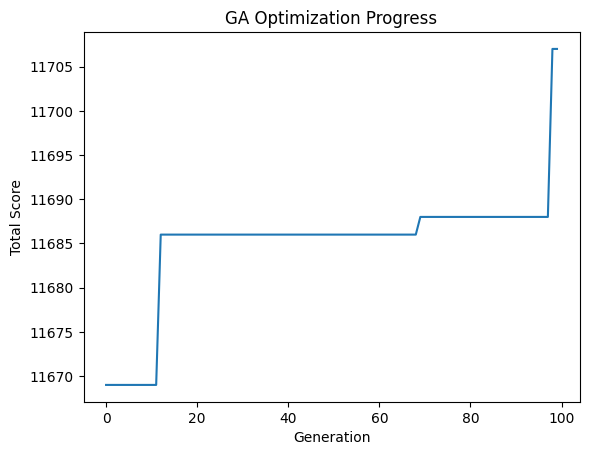

[(2, [28, 474]), (2, [196, 222]), (2, [441, 405]), (2, [333, 367]), (2, [423, 183]), (2, [93, 493]), (2, [369, 191]), (2, [190, 408]), (2, [420, 395]), (2, [35, 138]), (2, [286, 351]), (2, [252, 434]), (2, [97, 113]), (2, [197, 119]), (2, [47, 329]), (2, [482, 61]), (2, [33, 149]), (2, [12, 355]), (2, [326, 449]), (2, [300, 229]), (2, [165, 127]), (2, [14, 182]), (2, [315, 72]), (2, [170, 358]), (2, [306, 498]), (2, [421, 104]), (2, [330, 295]), (2, [454, 468]), (2, [322, 7]), (2, [256, 156]), (2, [279, 214]), (2, [299, 445]), (2, [1, 409]), (2, [414, 311]), (2, [189, 301]), (2, [17, 225]), (2, [352, 20]), (2, [212, 463]), (2, [492, 375]), (2, [86, 15]), (2, [334, 193]), (2, [154, 495]), (2, [462, 52]), (2, [64, 371]), (2, [410, 213]), (2, [73, 123]), (2, [120, 219]), (2, [319, 433]), (2, [443, 240]), (2, [21, 387]), (2, [158, 6]), (2, [337, 451]), (2, [141, 292]), (2, [11, 208]), (2, [266, 108]), (2, [261, 210]), (2, [155, 166]), (2, [38, 324]), (2, [448, 362]), (2, [0, 484]), (2, [45

In [69]:
#(teams,pizza_list) = load_problem("/Users/dgmendes/Documents/GitHub/AI_MECD06_Group_G/data/a_example")
(teams,pizza_list) = load_problem("/Users/dgmendes/Documents/GitHub/AI_MECD06_Group_G/data/b_little_bit_of_everything.in")
#(teams,pizza_list) = load_problem("/Users/dgmendes/Documents/GitHub/AI_MECD06_Group_G/data/c_many_ingredients.in")
# (teams,pizza_list) = load_problem("/Users/dgmendes/Documents/GitHub/AI_MECD06_Group_G/data/e_many_teams.in")

t2 = teams[2]
t3 = teams[3]
t4 = teams[4]
r = run_genetic_pizza(pizza_list,t2,t3,t4,100,100,False)
print(r)